In [1]:
# importing the necessary packages 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 

In [2]:
# impoting the train.csv ( i will still split the dataset in to train and test for the analysis)
accident = pd.read_csv("train.csv")

accident = accident.drop(columns="id")
#displaying the first 5 observations of the dataset
accident.head()


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [3]:
# checking the type of data in the variables 
accident.dtypes

road_type                  object
num_lanes                   int64
curvature                 float64
speed_limit                 int64
lighting                   object
weather                    object
road_signs_present           bool
public_road                  bool
time_of_day                object
holiday                      bool
school_season                bool
num_reported_accidents      int64
accident_risk             float64
dtype: object

In [4]:
# checking the shape of the dataset
accident.shape

(517754, 13)

In [5]:
# checking the accident risk variable 
maximum_accident_risk = accident["accident_risk"].max()
minimum_accident_risk = accident["accident_risk"].min()

print(f"The minimum accident risk prob is {minimum_accident_risk} and the maximum accident risk prob is {maximum_accident_risk}")

The minimum accident risk prob is 0.0 and the maximum accident risk prob is 1.0


In [6]:
# checkig for missing figures in the dataset
accident.isna().any(axis=0).sum()

np.int64(0)

In [7]:
# converting number of reported accidents into binary 0 and 1 by mapping 
accident['is_accident'] = pd.Series(np.where(accident['num_reported_accidents'] >0, 1, 0), index=accident.index)

# checking my dataset to see if it is well
accident.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,is_accident
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13,1
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35,0
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30,1
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21,1
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56,1


In [8]:
accident.dtypes

road_type                  object
num_lanes                   int64
curvature                 float64
speed_limit                 int64
lighting                   object
weather                    object
road_signs_present           bool
public_road                  bool
time_of_day                object
holiday                      bool
school_season                bool
num_reported_accidents      int64
accident_risk             float64
is_accident                 int64
dtype: object

In [9]:
# describing the dataset 
accident.describe()

,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk,is_accident
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,2.491511,0.488719,46.112575,1.187970,0.352377,0.758053
std,1.120434,0.272563,15.788521,0.895961,0.166417,0.428263
min,1.000000,0.000000,25.000000,0.000000,0.000000,0.000000
25%,1.000000,0.260000,35.000000,1.000000,0.230000,1.000000
50%,2.000000,0.510000,45.000000,1.000000,0.340000,1.000000
75%,3.000000,0.710000,60.000000,2.000000,0.460000,1.000000
max,4.000000,1.000000,70.000000,7.000000,1.000000,1.000000


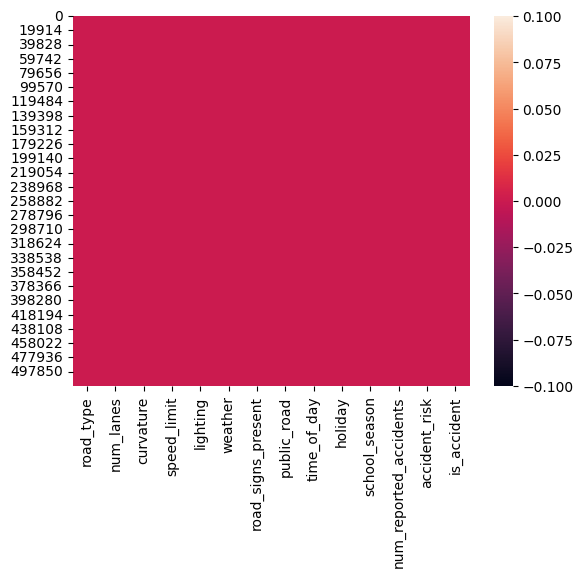

In [10]:
#another way to check for null variables using seaborn 
sns.heatmap(accident.isnull())

#showing the dataset 
plt.show()

## Converting categorical features

In [11]:
accident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               517754 non-null  object 
 1   num_lanes               517754 non-null  int64  
 2   curvature               517754 non-null  float64
 3   speed_limit             517754 non-null  int64  
 4   lighting                517754 non-null  object 
 5   weather                 517754 non-null  object 
 6   road_signs_present      517754 non-null  bool   
 7   public_road             517754 non-null  bool   
 8   time_of_day             517754 non-null  object 
 9   holiday                 517754 non-null  bool   
 10  school_season           517754 non-null  bool   
 11  num_reported_accidents  517754 non-null  int64  
 12  accident_risk           517754 non-null  float64
 13  is_accident             517754 non-null  int64  
dtypes: bool(4), float64(

In [12]:
accident.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,is_accident
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13,1
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35,0
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30,1
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21,1
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56,1


In [13]:
# dummying all categorical variables to be used 
#road_type
road_type = pd.get_dummies(accident['road_type'], drop_first=True)

#lighting 
lighting = pd.get_dummies(accident['lighting'], drop_first=True)

#weather 
weather = pd.get_dummies(accident['weather'], drop_first=True)

#time_of_the_day
time_of_the_day = pd.get_dummies(accident['time_of_day'], drop_first=True)

#dropping all the unneeded  columns 
#axis = 1 drops columns from the dataframes horizontally
#inplace = True modifies the dataframe instead of creating a new one 
accident.drop(['road_type', 'lighting', 'weather', 'time_of_day', 'num_reported_accidents'], axis=1, inplace=True)

#adding the new sets to the dataframe 
# axis = 1 Joins columns to the  dataframes horizontally
accident = pd.concat([accident, road_type, lighting, weather, time_of_the_day], axis =1) 


In [14]:
#displaying the first 5 items of the dataframe
accident.head()

,num_lanes,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,accident_risk,is_accident,rural,urban,dim,night,foggy,rainy,evening,morning
0,2,0.06,35,False,True,False,True,0.13,1,False,True,False,False,False,True,False,False
1,4,0.99,35,True,False,True,True,0.35,0,False,True,False,False,False,False,True,False
2,4,0.63,70,False,True,True,False,0.30,1,True,False,True,False,False,False,False,True
3,4,0.07,35,True,True,False,False,0.21,1,False,False,True,False,False,True,False,True
4,1,0.58,60,False,False,True,False,0.56,1,True,False,False,False,True,False,True,False


In [15]:
# constucting a binomial logistic regression
# loading the necessary packages 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [16]:
accident.dtypes

num_lanes               int64
curvature             float64
speed_limit             int64
road_signs_present       bool
public_road              bool
holiday                  bool
school_season            bool
accident_risk         float64
is_accident             int64
rural                    bool
urban                    bool
dim                      bool
night                    bool
foggy                    bool
rainy                    bool
evening                  bool
morning                  bool
dtype: object

In [17]:
#saving the x and y variables for training and testing 
X = accident[[
    "num_lanes",
    "curvature",
    "speed_limit",
    "road_signs_present",
    "public_road",
    "holiday",
    "school_season",
    "accident_risk",
    "rural",
    "urban",
    "dim",
    "night",
    "foggy",
    "rainy",
    "evening",
    "morning"]]

y = accident[['is_accident']]

In [18]:
# splitting the x and y variables for training and testing 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
# Building the classifier and fitting the model to the data  C = 0.1 prevents underfit , C= 1 regulization , C 
clf = LogisticRegression(class_weight='balanced', max_iter= 100000).fit(X=X_train, y=y_train)

c:\Users\12508\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [20]:
# Getting the coefficient (slope)
clf.coef_

array([[ 2.13381829e-02, -3.65140971e-01, -5.84492758e-03,
         8.37424977e-04, -2.49732608e-02, -4.63600867e-02,
        -3.46799553e-03,  1.51403651e+00, -2.63925489e-03,
         1.31632467e-02,  2.89910583e-02, -1.51038851e-01,
        -1.14832093e-01, -5.84676275e-02, -6.35128856e-03,
         4.95774543e-04]])

In [21]:
clf.intercept_

array([-0.0052219])

## Confusion Matrix 

In [22]:
# splitting the x and y variables for training and testing 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Building  regression model 
clf = LogisticRegression(class_weight='balanced', max_iter=1000).fit(X_train, y_train)

#getting preditions and saving them 
y_pred = clf.predict(X_test)

c:\Users\12508\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [23]:
#printing out predicted values 
clf.predict(X_test)

array([0, 0, 1, ..., 0, 1, 0], shape=(155327,))

In [24]:
#printing out the predicted probabilities 
clf.predict_proba(X_test)[::,-1]

array([0.4679193 , 0.46629638, 0.52104163, ..., 0.47590123, 0.52111432,
       0.44022904], shape=(155327,))

### Creating a confusion matrix

In [25]:
#importing the necessary packages 
import sklearn.metrics as metrics

In [26]:
# calculating the values for each quadrant in the confusion matrix
cm = metrics. confusion_matrix(y_test, y_pred, labels=clf.classes_)

In [27]:
#creating a confusion matrix as a visualization 
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

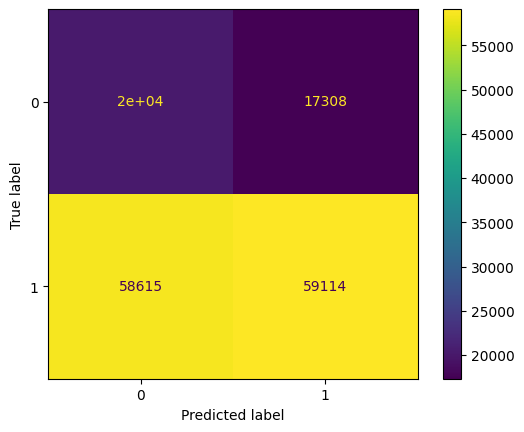

In [28]:
# Displaying the confusion matrix 
disp.plot()

#showing the plot
plt.show()

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.26      0.54      0.35     37598
           1       0.77      0.50      0.61    117729

    accuracy                           0.51    155327
   macro avg       0.52      0.52      0.48    155327
weighted avg       0.65      0.51      0.55    155327

